In [1]:
import sys
import os

# Get the current working directory of the notebook
current_notebook_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_notebook_dir, os.pardir))

# Add the parent directory to the Python path
sys.path.append(parent_dir)

In [2]:
import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from torchvision import models
import matplotlib.pyplot as plt

from data.datasets import DeepFakeDataset
from torchvision.models import resnet50, ResNet50_Weights, vit_b_32, ViT_B_32_Weights
import random
from sklearn.model_selection import train_test_split

In [3]:
SEED = 8
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
if torch.mps.is_available():
    torch.mps.manual_seed(SEED)

In [4]:
image_metadata_path = "../Deepfake-Eval-2024/image-metadata-publish.csv"
image_dir_path = '../Deepfake-Eval-2024/image-data'

In [5]:
image_metadata_df = pd.read_csv(image_metadata_path)

In [6]:
image_metadata_df[image_metadata_df['Filename']=='#NAME?']

,Filename,Date,Ground Truth,Public Comments,Finetuning Set


In [7]:
image_metadata_df = image_metadata_df[image_metadata_df['Filename']!='#NAME?'].reset_index(drop=True)
image_metadata_df.to_csv(image_metadata_path, index = False)

In [8]:
image_metadata_df.groupby('Ground Truth').agg({
    'Filename': 'count'
})

,Filename
Ground Truth,
Fake,1192
Real,760


In [9]:
image_metadata_df.groupby('Finetuning Set').agg({
    'Filename': 'count'
})

,Filename
Finetuning Set,
Test,786
Train,1166


In [10]:
existing_image_paths = []
missing_files_pre_check = []
for p in image_metadata_df['Filename']:
    if os.path.exists(os.path.join(image_dir_path, p)):
        existing_image_paths.append(p)
    else:
        missing_files_pre_check.append(p)

In [11]:
if missing_files_pre_check:
    print(f"Found {len(missing_files_pre_check)} missing files")
    for mf in missing_files_pre_check:
        print(mf)
else:
    print("All image files exist")

All image files exist


In [12]:
# Train test split
train_df, val_test_df = train_test_split(
    image_metadata_df,
    test_size=0.3, # 30% for validation and test
    stratify=image_metadata_df['Ground Truth'], # Stratify by the 'Ground Truth' column
    random_state=7
)

val_df, test_df = train_test_split(
    val_test_df,
    test_size=0.5, # 50% of the val_test_df (15% of original)
    stratify=val_test_df['Ground Truth'],
    random_state=7
)

In [13]:
train_image_metadata_path = "../image-metadata-train.csv"
val_image_metadata_path = "../image-metadata-val.csv"
test_image_metadata_path = "../image-metadata-test.csv"
train_df.to_csv(train_image_metadata_path, index = False)
val_df.to_csv(val_image_metadata_path, index = False)
test_df.to_csv(test_image_metadata_path, index = False)

In [14]:
def denormalize_image(tensor, mean, std):
    """
    Denormalizes a tensor (C, H, W) using the provided mean and standard deviation.
    """
    mean_tensor = torch.tensor(mean, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)
    std_tensor = torch.tensor(std, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)

    # Perform the denormalization operation
    denormalized_tensor = tensor * std_tensor + mean_tensor

    denormalized_tensor = torch.clamp(denormalized_tensor, 0.0, 1.0) # Assuming original values were in [0, 1]

    return denormalized_tensor

In [15]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

In [16]:
training_data_resnet = DeepFakeDataset(train_image_metadata_path, image_dir_path, model_type='ResNet', is_train=True)

In [17]:
training_dataloader = DataLoader(training_data_resnet, batch_size = 32, shuffle=True)

In [18]:
train_df.head()

,Filename,Date,Ground Truth,Public Comments,Finetuning Set
1532,OWbzmJcnMgQQJgocK45CBuj5rAs.jpg,########,Real,https://www.themirror.com/news/us-news/trump-s...,Train
1815,ncdagDm3zL9VUImyhlOEBCOKuVI.png,########,Real,https://www.independent.co.uk/news/world/europ...,Test
1088,FbPnuyTTAaCtV47FqZz7IzlAF5A.jpeg,5/3/2024,Fake,NaN,Test
1846,UFckik5M3SY1dMu5Llooa5Ayp0Y.png,########,Real,NaN,Test
1248,ZkVScOCz09y3xq8GC5wtugbfemM.jpg,########,Real,NaN,Test


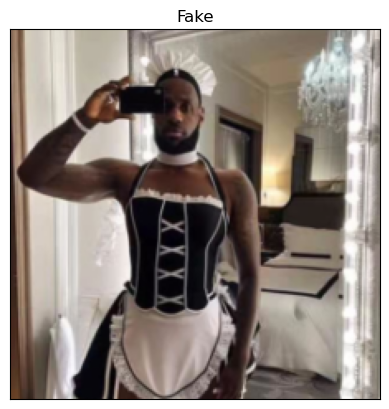

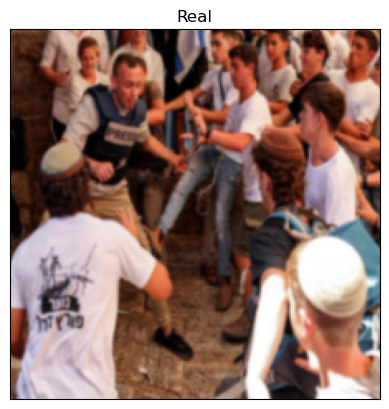

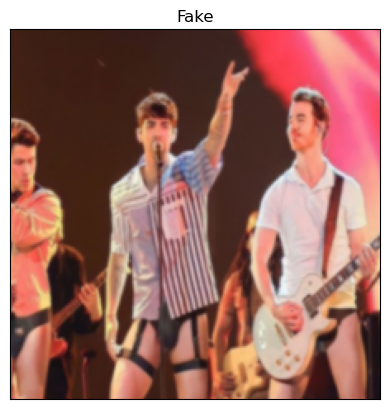

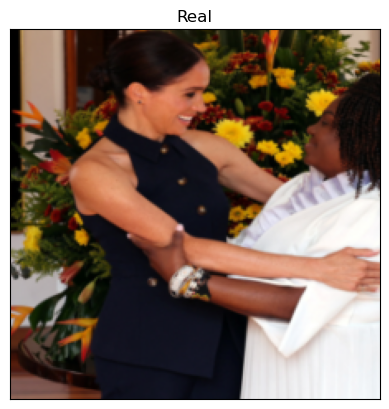

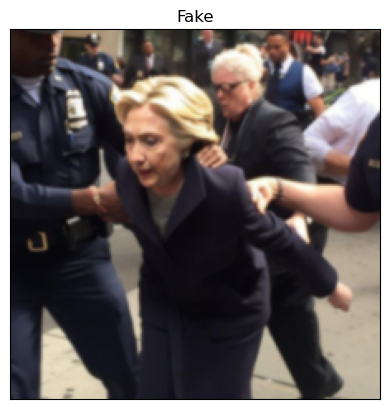

In [19]:
count = 0
features, label = next(iter(training_dataloader))
for i in range(5):
    img = features[i]
    denormalized_tensor = denormalize_image(img, mean, std)
    plt.imshow(np.transpose(denormalized_tensor, (1,2,0))) # convert pytorch tensor (3 channels, H, W) to numpy array (H, W, 3 channels)
    plt.title("Fake" if label[i] else "Real")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [20]:
val_data_resnet = DeepFakeDataset(val_image_metadata_path, image_dir_path, model_type='ResNet', is_train=False)
val_dataloader = DataLoader(val_data_resnet, batch_size = 32, shuffle=True)

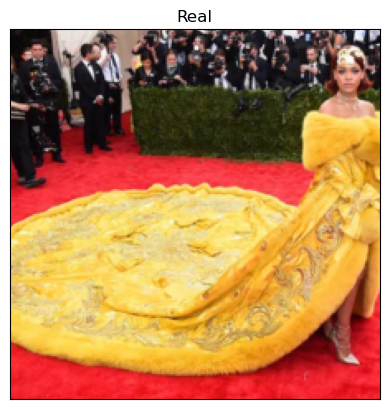

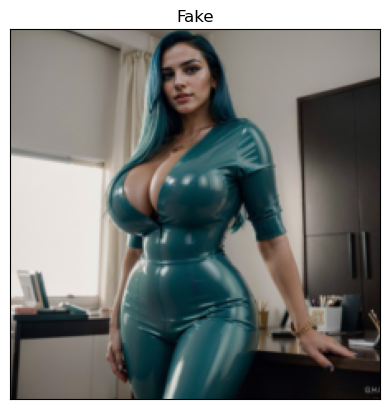

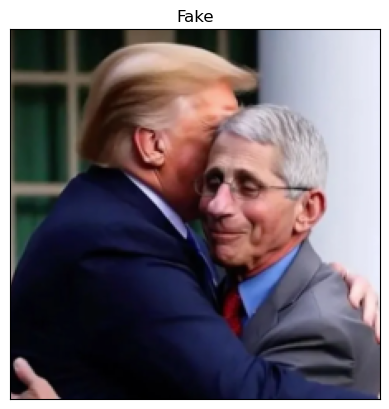

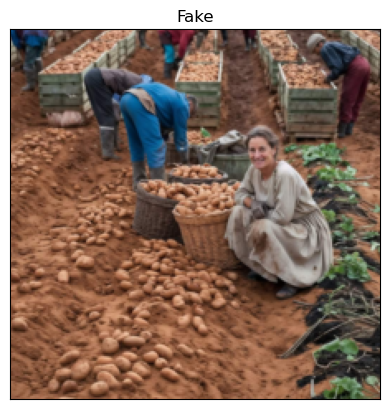

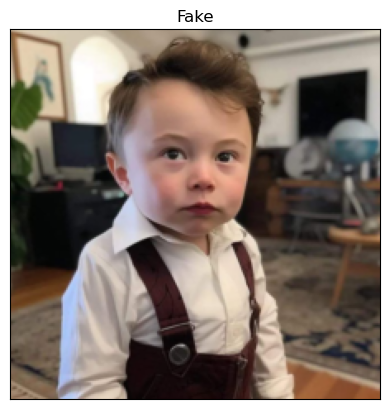

In [21]:
count = 0
features, label = next(iter(val_dataloader))
for i in range(5):
    img = features[i]
    denormalized_tensor = denormalize_image(img, mean, std)
    plt.imshow(np.transpose(denormalized_tensor, (1,2,0))) # convert pytorch tensor (3 channels, H, W) to numpy array (H, W, 3 channels)
    plt.title("Fake" if label[i] else "Real")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [ ]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', weights="ResNet50_Weights.IMAGENET1K_V1")
model.fc = nn.Identity()    # replace classification head with passthrough effectively removing last classification layer

In [ ]:
# extract features for train
resnet_features = model(features)

In [ ]:
resnet_features.shape